# Medical Cost Personal Dataset

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [58]:
df = pd.read_csv("insurance.csv")

In [59]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA (Exploratory Data Analysis)

In [61]:
print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [62]:
print(df.shape)        


(1338, 7)


In [63]:
print(df.dtypes)     


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [64]:
print(df.isnull().sum()) 


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [65]:
print(df.describe())   


               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [66]:
print(df.nunique()) 

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


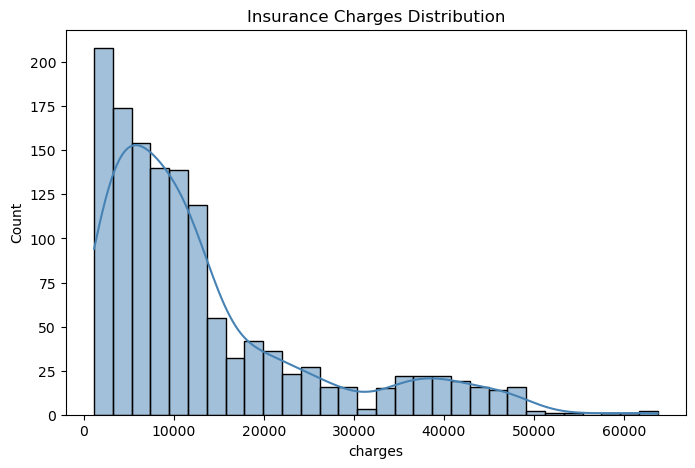

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


In [67]:
#  distribution insurance charges 
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True, color="steelblue")
plt.title("Insurance Charges Distribution")
plt.show()

# Basic stats of target
print(df["charges"].describe())

In [68]:
# See unique values
print(df["sex"].value_counts())
# male      676
# female    662

print(df["smoker"].value_counts())
# no     1064
# yes     274   smokers are minority

print(df["region"].value_counts())
# southeast    364
# southwest    325
# northwest    325
# northeast    324

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


# Correlation Matrix

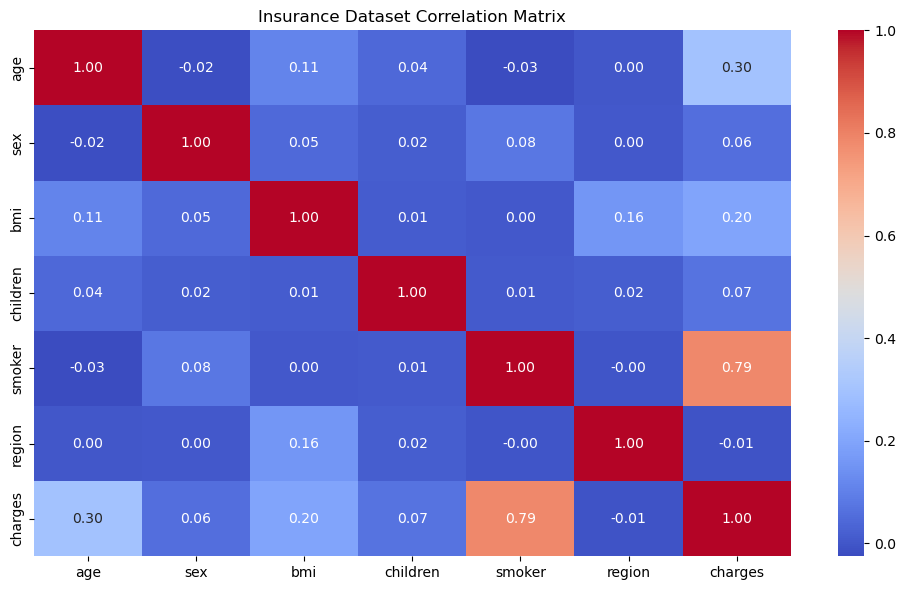

In [70]:
# First encode categoricals to see correlation
df_temp = df.copy()
df_temp["sex"]    = df_temp["sex"].map({"male": 1, "female": 0})
df_temp["smoker"] = df_temp["smoker"].map({"yes": 1, "no": 0})
df_temp["region"] = df_temp["region"].map({
    "northeast": 0, "northwest": 1,
    "southeast": 2, "southwest": 3
})

plt.figure(figsize=(10, 6))
sns.heatmap(df_temp.corr(), annot=True, 
            cmap="coolwarm", fmt=".2f")
plt.title("Insurance Dataset Correlation Matrix")
plt.tight_layout()
plt.show()

In [71]:


# 1. Encode smoker first
df["smoker_encoded"] = df["smoker"].map({"yes": 1, "no": 0})



# Feature Engineering

In [73]:
# adding new columns
df["smoker_bmi"]   = df["smoker_encoded"] * df["bmi"]
df["obese_smoker"] = ((df["bmi"] > 30) & (df["smoker"] == "yes")).astype(int)
df["age_group"]    = pd.cut(df["age"],bins=[0, 25, 40, 65],labels=["Young", "Middle", "Senior"])
df["bmi_category"] = pd.cut(df["bmi"],bins=[0, 18.5, 24.9, 30, 100],labels=["Underweight", "Normal","Overweight", "Obese"])

In [74]:
# Checking the new columns added
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'smoker_encoded', 'smoker_bmi', 'obese_smoker', 'age_group',
       'bmi_category'],
      dtype='object')


In [75]:
print(df.head())

   age     sex     bmi  children smoker     region      charges  \
0   19  female  27.900         0    yes  southwest  16884.92400   
1   18    male  33.770         1     no  southeast   1725.55230   
2   28    male  33.000         3     no  southeast   4449.46200   
3   33    male  22.705         0     no  northwest  21984.47061   
4   32    male  28.880         0     no  northwest   3866.85520   

   smoker_encoded  smoker_bmi  obese_smoker age_group bmi_category  
0               1        27.9             0     Young   Overweight  
1               0         0.0             0     Young        Obese  
2               0         0.0             0    Middle        Obese  
3               0         0.0             0    Middle       Normal  
4               0         0.0             0    Middle   Overweight  


# Encoding

In [77]:
#  Now one-hot encode
df["sex_encoded"] = df["sex"].map({"male": 1, "female": 0})

df["age_group"]    = df["age_group"].astype(str)

df["bmi_category"] = df["bmi_category"].astype(str)

df = pd.get_dummies(df, columns=["region", "age_group","bmi_category"], dtype=int)

# Drop original text columns (already encoded)
df.drop(columns=["sex", "smoker"], inplace=True)

print(df.shape)
df.columns.tolist()

(1338, 19)


['age',
 'bmi',
 'children',
 'charges',
 'smoker_encoded',
 'smoker_bmi',
 'obese_smoker',
 'sex_encoded',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'age_group_Middle',
 'age_group_Senior',
 'age_group_Young',
 'bmi_category_Normal',
 'bmi_category_Obese',
 'bmi_category_Overweight',
 'bmi_category_Underweight']

In [78]:
df.head()


,age,bmi,children,charges,smoker_encoded,smoker_bmi,obese_smoker,sex_encoded,region_northeast,region_northwest,region_southeast,region_southwest,age_group_Middle,age_group_Senior,age_group_Young,bmi_category_Normal,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,27.900,0,16884.92400,1,27.9,0,0,0,0,0,1,0,0,1,0,0,1,0
1,18,33.770,1,1725.55230,0,0.0,0,1,0,0,1,0,0,0,1,0,1,0,0
2,28,33.000,3,4449.46200,0,0.0,0,1,0,0,1,0,1,0,0,0,1,0,0
3,33,22.705,0,21984.47061,0,0.0,0,1,0,1,0,0,1,0,0,1,0,0,0
4,32,28.880,0,3866.85520,0,0.0,0,1,0,1,0,0,1,0,0,0,0,1,0


# Train Test Split

In [80]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=["charges"])
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1070, 18)
X_test: (268, 18)


# Feature Scaling

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling done")

Scaling done


# Model Training & Evaluation

In [118]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.svm import SVR

models = {
    "Linear Regression":    LinearRegression(),
    "Random Forest":        RandomForestRegressor(random_state=42),
    "Gradient Boosting":    GradientBoostingRegressor(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"{name:25} RMSE: {rmse:.2f}  |  R²: {r2:.2f}")

Linear Regression         RMSE: 4203.44  |  R²: 0.89
Random Forest             RMSE: 4583.36  |  R²: 0.86
Gradient Boosting         RMSE: 4343.34  |  R²: 0.88


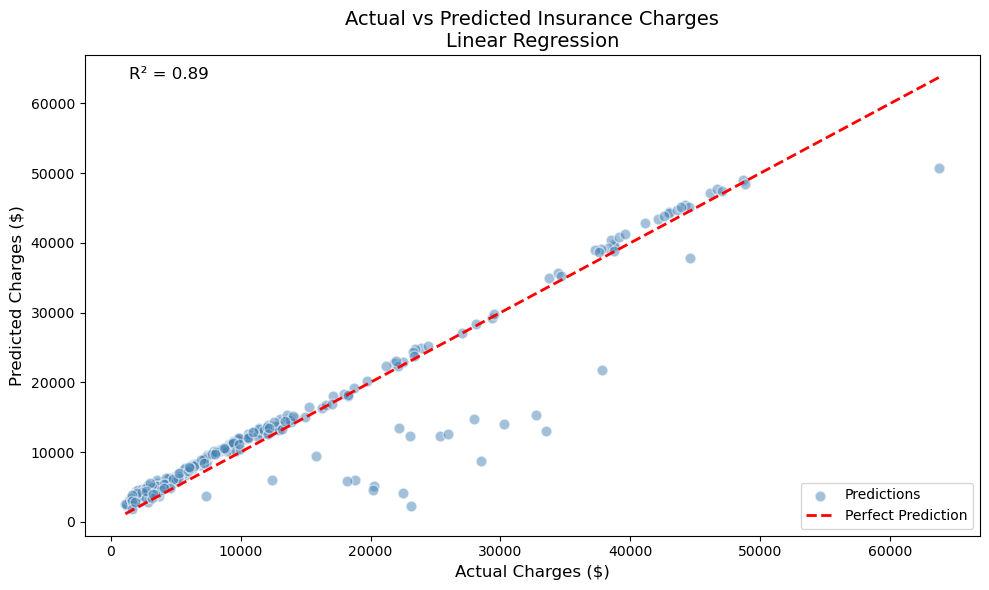

In [116]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred,alpha=0.5,color="steelblue",edgecolors="white",s=60,label="Predictions")

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linewidth=2,linestyle="--",label="Perfect Prediction")

# Add R² to plot
r2 = r2_score(y_test, y_pred)
plt.text(0.05, 0.95, f"R² = {r2:.2f}",transform=plt.gca().transAxes,fontsize=12,color="black")

plt.xlabel("Actual Charges ($)",  fontsize=12)
plt.ylabel("Predicted Charges ($)", fontsize=12)
plt.title("Actual vs Predicted Insurance Charges\nLinear Regression", 
          fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

here linear regression is the best model, improving linear regression in the grid searchcv won't bring any improvement so we use Gradient Boosting 

# Hyperparameter Tuning (GridSearchCV)

In [110]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best R²:",     grid.best_score_)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best R²: 0.8468941020918332


here , by doing gridsearchCV it didn't improve the r2_score so, we use the linear regression model.

# conclusion

This project predicted medical insurance charges using patient data with 1338 records.From EDA smoking status was found to be the strongest predictor with a correlation of 0.79. Age and BMI had moderate effect while region and gender had almost no impact on charges.

Three models were compared:
 * Linear Regression   R² 0.89  
 * Gradient Boosting   R² 0.88  
 * Random Forest       R² 0.87  

Linear Regression was the best model explaining 89% of the variation in insurance charges with an average prediction error of $4202.
GridSearchCV on Gradient Boosting could not beat Linear Regression confirming that the relationships in this data are linear.